In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Let us study how the entropy and cross entropy behave in general the we move to Logistic Models

# Entropy and Cross Entropy

In [2]:
def log2(x):
    if not isinstance(x,np.ndarray): x = np.array(x)
    xx= x.copy()
    xx[xx==0]=1                                             #handle 0 and 1 
    return np.log2(xx)

def H_2(x,t):     # cross entropy for a dataset of binary class i.e. Bernoulli distribution
    return -(t*log2(x) + (1-t)*log2(1-x))


def H2(x):       # entropy for a dataset of binary class i.e. Bernoulli distribution
    return H_2(x,x)

# print(H_2(np.array([0.1,0]),np.array([1,1])))
# print(H2(np.array([1,1/2,.3])))
# H2(0.1)


Below are just made up number based on figure 7 in unit5

In [3]:
TN = H_2(0.1,0) + H_2(0.1,0) + H_2(0.2,0) + H_2(0.2,0) # correctly classified negative class
FN = H_2(0.6,0) + H_2(0.6,0) + H_2(0.7,0) + H_2(0.7,0) # incorrectly classfied negatove class
print(TN, FN)

# we could do also an array in one call
TN = H_2(np.array([.1, .1, .2, .2]), np.array([0, 0, 0, 0]))
FN = H_2(np.array([.6, .6, .7, .7]), np.array([0, 0, 0, 0]))

print(TN.sum(), FN.sum())

0.9478623766648245 6.117787378107136
0.9478623766648245 6.117787378107136


In [4]:
# cross entropy for decison bondaries 1
FP = 2*H_2(0.55,0)               # incorrectly classfied as psoitive class
FN =   H_2(0.45,1)               # incorrectly classfied as negative class
TN = 7*H_2(0.1, 0)               #  correctly classified as negative class
TP = 6*H_2(0.9, 0)               #  correctly classified as positive class
CrossEntropyAll = TN+TP+FN+TN
print(CrossEntropyAll)

23.21161497099993


In [5]:
# cross entropy for decison bondaries 2
FP = 4*H_2(0.55,0)               # incorrectly classfied as psoitive class
FN =   0#H_2(0.45,1)               # incorrectly classfied as negative class
TN = 5*H_2(0.1, 0)               #  correctly classified as negative class
TP = 7*H_2(0.9, 0)               #  correctly classified as positive class
CrossEntropyAll = TN+TP+FN+TN
print(CrossEntropyAll)

24.773527598662042


# Logistic Model Inference 

In [6]:
# generate the data
def getMdl(x1, c=-4):
    return 2*x1 + c
    
def getData(n  = 10):
    
    x1 = np.linspace(30, 60, num = n) # this sampling unifromally from the x axis
    x2 = getMdl(x1) #2*x1 - 4 #12

    X1 = x1                           # get the first attribute
    X2 = np.random.normal(x2,20)      # get the second attribute (add noise so data is realistic)
    

    return X1, X2, x1, x2


X1, X2, x1, x2 = getData()

In [7]:
def LinC12(X1, X2 ):
    
    LM = -X2 + getMdl(X1) #2*X1 - 4  # linear model decision boundary
    ind1 = LM >=  0
    ind0 = LM <   0

    C1 = [X1[ind1],X2[ind1]]       # Actual Class1
    C0 = [X1[ind0],X2[ind0]]       # Actual Class0
    
    targets = ind1*1.0             # targets can be deduced form the positive class     
    
    return C1, C0, LM, targets

C1, C0, LM1, targets = LinC12(X1, X2) # separate the classes with a linear boundaries

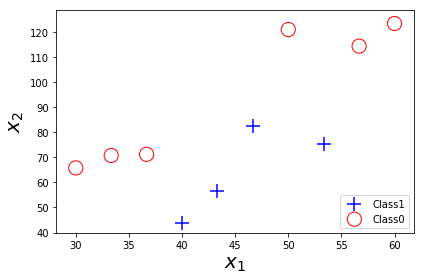

In [8]:
def plotC12(C0, C1):
    plt.scatter(C1[0],C1[1], s=200,color='b',    marker='+', label= 'Class1')
    plt.scatter(C0[0],C0[1], s=200,color='none', marker='o', label= 'Class0', edgecolor='red')
    
    #plt.scatter(C1[0],C1[1], s=200,color='b', marker='o')
    #plt.scatter(C0[0],C0[1], s=200,color='b', marker='o')
    
    plt.xlabel('$x_1$',fontsize=20)
    plt.ylabel('$x_2$',fontsize=20)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('figures\LogisticRegressionComparisonData1.png')

plotC12(C0, C1)                        # plot the two classes
#plt.plot(x1,x2,'b')                   # plot the boundary


# save a nice data
#C1_, C0_ = C1, C0





## Logistic Function Decision Making

Below we can see logistic is very resilient to the thershold and saturate quite quickly 
so unless threshold is close to 0 or 1 it will not change the calssificaiton decision

In [9]:
def sig(z):
    return 1/(1 + np.exp(-z))

def LgC12(X1, X2, LM, targets):       # get logistic regresion classes
    threshold = 0.5                   # 0.999  # 0.0001 # 0.6  # 0.8 # 0.9 # try these
    LGM = sig(LM)                     # Logistic Model
    
    ind1 = (LGM >= threshold )        # Decision Making is here.................!
    ind0 = (LGM <  threshold )        # Decision Making is here.................!
    
    ##print(np.sort(sig(z)))
    #plt.plot(np.sort(sig(z)))

    C1_ = [X1[ind1],X2[ind1]]         # predicted Class1
    C0_ = [X1[ind0],X2[ind0]]         # predicted Class0
    
    CH  = H_2(LGM,targets).sum()      # cross entropy
    
    return CH, LGM, C1_, C0_

below we see how the decision boundary of z and its segmoid decision making are alligned 

In [10]:
def plotLgM(C1_, C0_, C1, C0, ax):
    
    ax.scatter(C1[0], C1[1], s=500,color='b',     marker='+', label= 'Actual Class1')
    ax.scatter(C0[0], C0[1], s=500,color='none',  marker='o', label= 'Actual Class0', edgecolor='red')

    ax.scatter(C1_[0],C1_[1], s=200,color='none', marker='s', label= 'Predicted Class1', edgecolor='k')
    ax.scatter(C0_[0],C0_[1], s=200,color='g',    marker='o', label= 'Predicted Class0')
    
    
    ax.legend()

## Comparison between Two Different Logistic Models

Ok let us put everything together now to compare between two logistic models (remember they differ in thier linear model).

Note that there is no model fitting here.

In [11]:

X0   = np.ones(len(X1)) 
X    = np.array([X0,X1,X2])

w1   = np.array([-4, 2, -1]) # -4 is the deafult for getMdl so it is the original decision boundary
w2   = np.array([10, 2, -1]) # change the decision boudndary and see the effect on the cross entropy
x2_  = getMdl(x1, w2[0])     # obtain the new decision boundary for plotting later

# Lm1  = -X2 + 2*X1 - 4    # linear model 1
# Lm2  = -X2 + 2*X1 - 10   # linear model 2
Lm1  = w1.dot(X)           # linear model 1
Lm2  = w2.dot(X)           # linear model 2

Lg1  = sig(Lm1)            # logistic model 1
Lg2  = sig(Lm2)            # logistic model 2

CE1 = H_2(Lg1,targets)     # cross entropy for model 1
CE2 = H_2(Lg2,targets)     # cross entropy for model 1

data = [X0,X1,X2,targets, Lm1, Lg1, CE1, Lm2, Lg2, CE2 ]
data = np.round(np.array(data).T,2)
print(CE1.sum(), CE2.sum())

columns = ['X0', 'X1', 'X2', 'targets', 'w1^Tx', 'sig(w1^Tx)', 'CrossEnt1', 'w2^Tx', 'sig(w2^Tx)', 'CrossEnt2' ]
df = pd.DataFrame(data, columns=columns)
df.to_csv('./crossEntropytable.csv')
print(df)

0.2131801975032756 54.280058835132046
    X0     X1      X2  targets  w1^Tx  sig(w1^Tx)  CrossEnt1  w2^Tx  \
0  1.0  30.00   65.80      0.0  -9.80        0.00       0.00   4.20   
1  1.0  33.33   70.76      0.0  -8.09        0.00       0.00   5.91   
2  1.0  36.67   71.23      0.0  -1.90        0.13       0.20  12.10   
3  1.0  40.00   43.96      1.0  32.04        1.00       0.00  46.04   
4  1.0  43.33   56.70      1.0  25.97        1.00       0.00  39.97   
5  1.0  46.67   82.47      1.0   6.86        1.00       0.00  20.86   
6  1.0  50.00  121.08      0.0 -25.08        0.00       0.00 -11.08   
7  1.0  53.33   75.31      1.0  27.35        1.00       0.00  41.35   
8  1.0  56.67  114.45      0.0  -5.12        0.01       0.01   8.88   
9  1.0  60.00  123.49      0.0  -7.49        0.00       0.00   6.51   

   sig(w2^Tx)  CrossEnt2  
0        0.99       6.09  
1        1.00       8.52  
2        1.00      17.46  
3        1.00      -0.00  
4        1.00      -0.00  
5        1.00     

Cross Entropy for Logistic Model1 =  0.2131801975032756
Cross Entropy for Logistic Model1 =  54.280058835132046


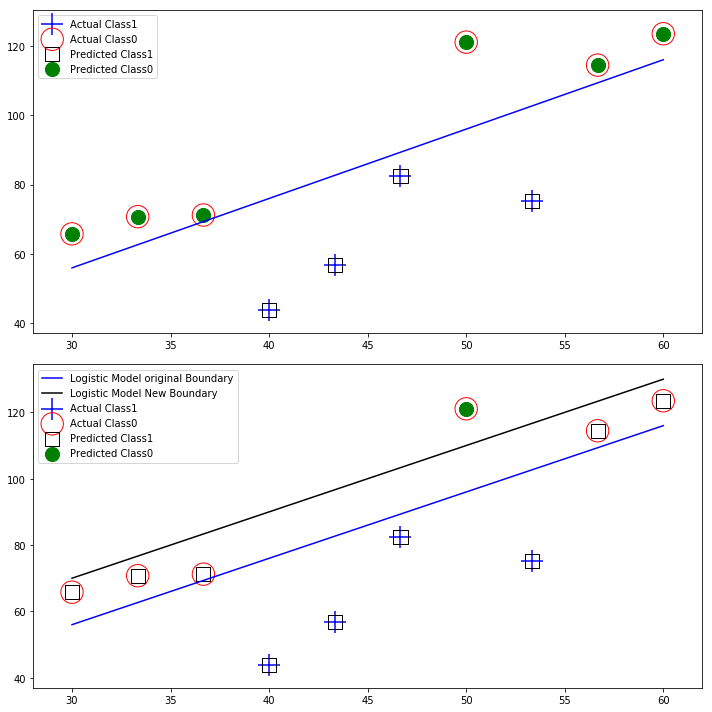

In [12]:
def getLg_PlotLg(Lm,ax):
    # Logistic Regression Model 1....................
    CH, LgM, C1_, C0_ = LgC12(X1, X2, Lm, targets)    # will generate a correctly calssfied data
    print('Cross Entropy for Logistic Model1 = ', CH)
    plotLgM(C1_,C0_, C1, C0, ax)
    

fig = plt.figure(figsize=(10,10))
ax1, ax2 = fig.subplots(2)

# Logistic Regression Model 1....................
getLg_PlotLg(Lm1,ax1)
ax1.plot(x1, x2, 'b', label= 'Logistic Model original Boundary' )

# Logistic Regression Model 2....................
getLg_PlotLg(Lm2, ax2)
ax2.plot(x1, x2, 'b', label= 'Logistic Model original Boundary' )
ax2.plot(x1,x2_,'k', label= 'Logistic Model New Boundary' )

plt.legend()
plt.tight_layout()
plt.savefig('figures\LogisticRegressionCompariosn.png')

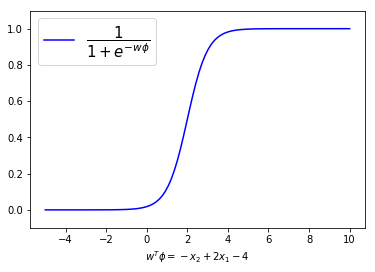

In [13]:
x1 = np.linspace(-5, 10, num = 100)
x2 = 2*x1 - 4

plt.plot(x1, sig(x2),'b-', label='$\dfrac{1}{1+e^{-w\phi}}$')
plt.xlabel('$w^T\phi=-x_2 + 2x_1 - 4$')

plt.ylim([-0.1,1.1])
plt.legend(prop={"size":15})
